<a href="https://colab.research.google.com/github/Fedelberg/python_project/blob/main/Predicting_Apartment_Prices_in_Buenos_Aires.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Apartment Prices in Buenos Aires**

## **Purpose:**
The goal of this project is to predict apartment prices in Buenos Aires using key property features such as size (area), location (latitude and longitude), and neighborhood.

The project aims to:

- Help buyers and sellers understand how property characteristics affect price.
- Provide a data-driven tool for estimating apartment value across different parts of the city.
- Demonstrate how machine learning can support real estate decision-making through interpretable visualizations and models.

#**Q1. Predicting Price with Size**

In [ ]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.3 MB/s eta 0:00:00


In [ ]:
from glob import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded = files.upload()
uploaded = files.upload()
uploaded = files.upload()
uploaded = files.upload()


Saving buenos_aires_real_estate1.xlsx to buenos_aires_real_estate1.xlsx


Saving buenos_aires_real_estate2.xlsx to buenos_aires_real_estate2.xlsx


Saving buenos_aires_real_estate3.xlsx to buenos_aires_real_estate3.xlsx


Saving buenos_aires_real_estate4.xlsx to buenos_aires_real_estate4.xlsx


Saving buenos_aires_real_estate5.xlsx to buenos_aires_real_estate5.xlsx


In [ ]:
# Get the uploaded file name
buenos_aires_real_estate1 = "buenos_aires_real_estate1.xlsx"
# Read the Excel file into a pandas DataFrame
df1 = pd.read_excel(buenos_aires_real_estate1)

# Display the DataFrame
print(df1.shape)
print(df1.head())

(8606, 16)
  operation property_type                            place_with_parent_names  \
0      sell     apartment           |Argentina|Capital Federal|Villa Crespo|   
1      sell         house  |Argentina|Bs.As. G.B.A. Zona Oeste|La Matanza...   
2      sell         house  |Argentina|Bs.As. G.B.A. Zona Oeste|MorÃ³n|Cas...   
3      sell         house  |Argentina|Bs.As. G.B.A. Zona Oeste|Tres de Fe...   
4      sell     apartment              |Argentina|Capital Federal|Chacarita|   

                         lat-lon     price currency  \
0  -34.6047834183,-58.4586812499  180000.0      USD   
1                            NaN  250000.0      USD   
2         -34.6497002,-58.658073  410000.0      USD   
3        -34.5957086,-58.5669503  180000.0      USD   
4  -34.5846508988,-58.4546932614  129000.0      USD   

   price_aprox_local_currency  price_aprox_usd  surface_total_in_m2  \
0                   2729232.0         180000.0                120.0   
1                   3790600.0      

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8606 entries, 0 to 8605
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   8606 non-null   object 
 1   property_type               8606 non-null   object 
 2   place_with_parent_names     8606 non-null   object 
 3   lat-lon                     6936 non-null   object 
 4   price                       7590 non-null   float64
 5   currency                    7590 non-null   object 
 6   price_aprox_local_currency  7590 non-null   float64
 7   price_aprox_usd             7590 non-null   float64
 8   surface_total_in_m2         5946 non-null   float64
 9   surface_covered_in_m2       7268 non-null   float64
 10  price_usd_per_m2            4895 non-null   float64
 11  price_per_m2                6520 non-null   float64
 12  floor                       1259 non-null   float64
 13  rooms                       4752 

In [ ]:
def wrangle(filepath):
    # Read Excel file
    df = pd.read_excel(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Get place name
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand=True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    #Drop features with high null counts
    df.drop(columns=["floor", "expenses"], inplace=True)

    # Drop  high- and low-cardinality categorical variables
    df.drop(columns=["operation", "property_type", "properati_url", "currency"], inplace=True)

    #Drop leakage columns
    df.drop(
        columns=[
            "price",
            "price_aprox_local_currency",
            "price_per_m2",
            "price_usd_per_m2"
        ],
        inplace=True
    )

    #drop column with multi-collinearlity
    df.drop(columns=["surface_total_in_m2", "rooms"], inplace=True)


    return df

## **Wrangle function explained**

**Subsetting data based on criteria:**
This step focuses the analysis on only "apartments" in "Capital Federal" where price is less than "$400_000", which is relevant to the task of predicting apartment prices in Buenos Aires. It removes irrelevant data that would not be included in the analysis.

**Removing outliers for "surface_covered_in_m2":**
This step helps to handle outliers in the covered surface area that could potentially skew the results of a linear model. By keeping data within a certain range, the model is less likely to be unduly influenced by extreme values.

**Splitting "lat-lon" column:**
These steps splits the "lat-lon" string column into two separate columns, "lat" and "lon", based on the comma delimiter. It also converts the resulting columns to a float datatype and removes the original "lat-lon" column.It extract geographical features for location-based modeling.

**Getting place name (neighborhood):**
This extracts the specific neighborhood information, which wil be a valuable categorical feature for predicting apartment price  with neighborhood.

**Dropping features with high null counts:**
These columns had a significant number of missing values, as seen in the initial data exploration. Removing them prevents issues with missing data during model training and avoids using features that may not be reliable due to incompleteness.

**Dropping high- and low-cardinality categorical variables:**
These columns were not useful for the prediction task as it contain too many unique values (like URLs,"operation = Sales", "property_type", "currency") , Keeping only meaningful and manageable variables.

**Dropping leakage columns:**
These columns are directly related to the target variable "price" from it. Including them as features would lead to data leakage, where the model would have access to information it wouldn't have in a real-world prediction scenario, resulting in an overly optimistic evaluation of the model's performance.

**Dropping column with multicollinearity:**
"surface_total_in_m2" was highly correlated with "surface_covered_in_m2", and "rooms" and also correlated with the area. Removing these helps to mitigate multicollinearity, a situation where independent variables in a regression model are highly correlated, which can make the model less stable and harder to

In [ ]:
df = wrangle("buenos_aires_real_estate1.xlsx")
print("df shape:", df.shape)
df.head()

df shape: (1343, 5)


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,ConstituciÃ³n
41,90000.0,50.0,-34.610610,-58.412511,Once


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 4 to 8604
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        1343 non-null   float64
 1   surface_covered_in_m2  1343 non-null   float64
 2   lat                    1300 non-null   float64
 3   lon                    1300 non-null   float64
 4   neighborhood           1343 non-null   object 
dtypes: float64(4), object(1)
memory usage: 63.0+ KB


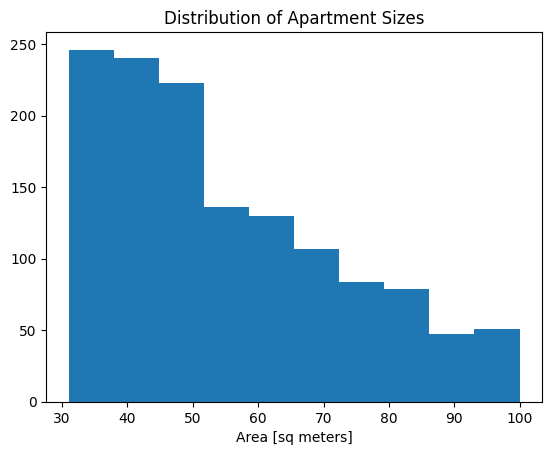

In [ ]:
plt.hist(df["surface_covered_in_m2"])
plt.xlabel("Area [sq meters]")
plt.title("Distribution of Apartment Sizes");

This plot shows that majority of apartments fall within the 30–50 m². This suggests that compact apartments like one-bedroom units are the most common in the dataset — likely catering to singles or small households. As apartment area increases beyond 50 m², the number of listings drops sharply. Apartments larger than 70–80 m² are relatively rare, and those above 90 m² are uncommon

In [ ]:
df.describe()["surface_covered_in_m2"]

,surface_covered_in_m2
count,1343.000000
mean,55.076694
std,18.160427
min,31.000000
25%,40.000000
50%,50.000000
75%,68.500000
max,100.000000


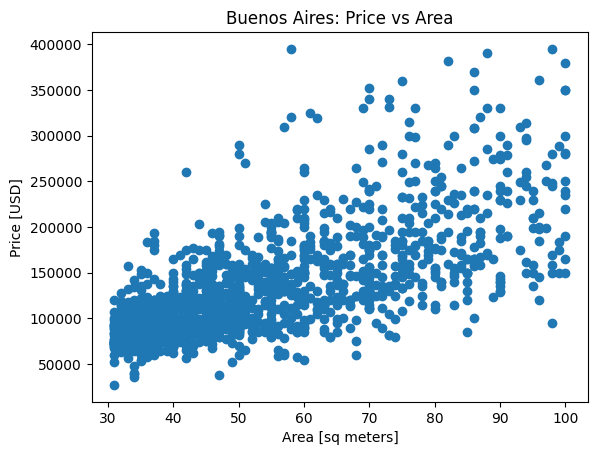

In [ ]:
plt.scatter(x=df["surface_covered_in_m2"], y=df["price_aprox_usd"])
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs Area");

The scatter plot shows a Positive correlation between property price (in USD) and area (in square meters), as the area increases, the price generally increases. **Larger properties tend to cost more.**
Even though the general trend is positive, there’s a wide spread of prices for properties of similar sizes.
For example, properties around 60–70 m² range from roughly $50,000  to over $300,000. This suggests that other factors (like location, building condition, or amenities) also strongly influence prices.

#split


In [ ]:
features = ["surface_covered_in_m2"]
X_train = df[features]
X_train.shape

(1343, 1)

In [ ]:
target = "price_aprox_usd"
y_train = df[target]
y_train.shape

(1343,)

#**Build model**

**Baseline**

In [ ]:
y_mean = y_train.mean()
y_mean

np.float64(135527.83871928515)

In [ ]:
y_pred_baseline = [y_mean] * len(y_train)
len(y_pred_baseline)

1343

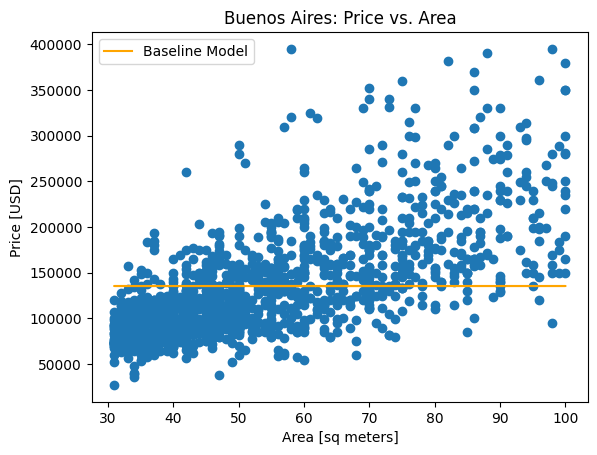

In [ ]:
# Add a line to the plot
plt.plot(X_train.values, y_pred_baseline, color="orange", label="Baseline Model")

plt.scatter(X_train, y_train)
plt.xlabel("Area [sq meters]")
plt.ylabel("Price [USD]")
plt.title("Buenos Aires: Price vs. Area")
plt.legend();

In [ ]:
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 135527.84
Baseline MAE: 45199.46


**Iterate**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_training = model.predict(X_train)
y_pred_training[:5]

array([169151.87330223, 106064.44707446, 133101.91545779, 106064.44707446,
       124089.42599668])

In [ ]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 31248.26


In [ ]:
X_test = wrangle("/content/buenos_aires_real_estate1.xlsx")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

,0
0,169151.873302
1,106064.447074
2,133101.915458
3,106064.447074
4,124089.425997


# **Communicate Results**

In [ ]:
intercept = round(model.intercept_,2)
print("Model Intercept:", intercept)
assert any([isinstance(intercept, int), isinstance(intercept, float)])

Model Intercept: 11433.31


In [ ]:
coefficient = round(model.coef_[0],2)
print('Model coefficient for "surface_covered_in_m2":', coefficient)
assert any([isinstance(coefficient, int), isinstance(coefficient, float)])

Model coefficient for "surface_covered_in_m2": 2253.12


In [ ]:
print(f"apartment_price = {intercept} + {coefficient} * surface_covered")

apartment_price = 11433.31 + 2253.12 * surface_covered


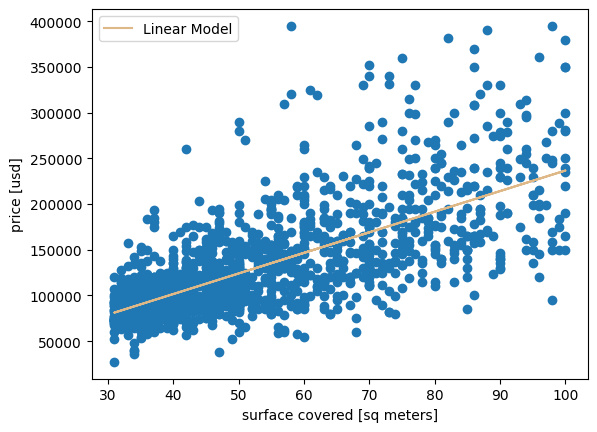

In [ ]:
# Add a line to the plot
plt.plot (X_train, model.predict(X_train), color= "burLywood", label = "Linear Model")

plt.scatter(X_train, y_train)
plt.xlabel("surface covered [sq meters]")
plt.ylabel("price [usd]")
plt.legend();

The Points close to the line indicate that model predicts prices accurately.

Points far above or below the line shows properties that are priced higher or lower than expected based on their size

# **Q2. Predicting Price with Location**

In [ ]:
frame1 = wrangle("buenos_aires_real_estate1.xlsx")
print(frame1.info())
frame1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 4 to 8604
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        1343 non-null   float64
 1   surface_covered_in_m2  1343 non-null   float64
 2   lat                    1300 non-null   float64
 3   lon                    1300 non-null   float64
 4   neighborhood           1343 non-null   object 
dtypes: float64(4), object(1)
memory usage: 63.0+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,ConstituciÃ³n
41,90000.0,50.0,-34.610610,-58.412511,Once


In [ ]:
frame2 = wrangle("buenos_aires_real_estate2.xlsx")
frame2.head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
2,215000.00,35.0,-34.588993,-58.400133,Recoleta
9,341550.00,90.0,-34.588044,-58.398066,Recoleta
12,91156.62,33.0,-34.623320,-58.397461,Monserrat
13,105000.00,33.0,-34.553897,-58.451939,Belgrano
17,89681.00,39.0,-34.628813,-58.472230,Villa del Parque


In [ ]:
df = pd.concat([frame1, frame2], ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        2658 non-null   float64
 1   surface_covered_in_m2  2658 non-null   float64
 2   lat                    2561 non-null   float64
 3   lon                    2561 non-null   float64
 4   neighborhood           2658 non-null   object 
dtypes: float64(4), object(1)
memory usage: 104.0+ KB
None


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,129000.0,70.0,-34.584651,-58.454693,Chacarita
1,87000.0,42.0,-34.638979,-58.500115,Villa Luro
2,118000.0,54.0,-34.615847,-58.459957,Caballito
3,57000.0,42.0,-34.625222,-58.382382,ConstituciÃ³n
4,90000.0,50.0,-34.610610,-58.412511,Once


In [ ]:
fig = px.scatter_mapbox(
    df,   # Our DataFrame
    lat= "lat",
    lon= "lon",
    width=600,   # Width of map
    height=600,  # Height of map
    color= "price_aprox_usd",
    hover_data=["price_aprox_usd"],  # Display price when hovering mouse over house
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

This map-plot indicating that the bulk of property listings come from the city center and nearby neighborhoods. The brighter colors are mostly concentrated in central and northern areas, suggesting that these neighborhoods are more expensive, while southern and eastern areas tend to be more affordable.

In [ ]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x= "lat",
    y= "lon",
    z= "price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()

This 3D view reinforces earlier findings, Prices (the vertical axis) range mostly between 50Kand300K, with a few properties reaching around $400K. The spread of prices suggests that while many listings fall within a mid-range price band, some premium properties exist within the same geographic zones.

**Split**

In [ ]:
features = ["lon", "lat"]
X_train = df[features]
X_train.head()

,lon,lat
0,-58.454693,-34.584651
1,-58.500115,-34.638979
2,-58.459957,-34.615847
3,-58.382382,-34.625222
4,-58.412511,-34.610610


In [ ]:
target = "price_aprox_usd"
y_train = df[target]
y_train.head()

,price_aprox_usd
0,129000.0
1,87000.0
2,118000.0
3,57000.0
4,90000.0


**Build model**

**baseline**

In [ ]:
y_mean = y_train.mean()

In [ ]:
y_pred_baseline = [y_mean] * len(y_train)
y_pred_baseline[:5]

[np.float64(134732.97340481562),
 np.float64(134732.97340481562),
 np.float64(134732.97340481562),
 np.float64(134732.97340481562),
 np.float64(134732.97340481562)]

In [ ]:
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 134732.97
Baseline MAE: 45422.75


**Iterate**

In [ ]:
imputer = SimpleImputer()
imputer.fit(X_train)

SimpleImputer()

In [ ]:
#Transform Data
XT_train = imputer.transform(X_train)
pd.DataFrame(XT_train, columns=X_train.columns).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lon     2658 non-null   float64
 1   lat     2658 non-null   float64
dtypes: float64(2)
memory usage: 41.7 KB


In [ ]:
#create a pipeline
model = make_pipeline(
    SimpleImputer(),
    LinearRegression()
)

In [ ]:
#fit model
model.fit(X_train, y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('linearregression', LinearRegression())])

**Evaluation**

In [ ]:
y_pred_training = model.predict(X_train)

In [ ]:
mae_training = mean_absolute_error(y_train,y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 42962.72


In [ ]:
X_test = wrangle("buenos_aires_real_estate2.xlsx")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

,0
0,149013.260952
1,150146.267425
2,123262.469029
3,165687.039507
4,104349.818583


# Communicate Results

In [ ]:
intercept = model.named_steps["linearregression"].intercept_.round()
coefficients = model.named_steps["linearregression"].coef_.round()
#intercept
coefficients

array([196709., 765467.])

In [ ]:
print(
    f"price = {intercept} + ({coefficients[0]} * longitude) + ({coefficients[1]} * latitude)"
)

price = 38113587.0 + (196709.0 * longitude) + (765467.0 * latitude)


In [ ]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x= "lon",
    y= "lat",
    z= "price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Create x and y coordinates for model representation
x_plane = np.linspace(df["lon"].min(), df["lon"].max(), 10)
y_plane = np.linspace(df["lat"].min(), df["lat"].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

# Use model to predict z coordinates
z_plane = model.predict(pd.DataFrame({"lon": x_plane, "lat": y_plane}))
zz = np.tile(z_plane, (10, 1))

# Add plane to figure
fig.add_trace(go.Surface(x=xx, y=yy, z=zz))

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()

This plot visually communicates how location influences property price.

Areas toward the yellow regions are predicted to have higher prices, meaning the model identifies these zones as more valuable or desirable.

Areas in purple are predicted to have lower prices, possibly representing less central or less attractive regions.

# **Q3 Predicting Price with Neighborhood**

In [ ]:
files =  glob("buenos_aires_real_estate*.xlsx")
files

['buenos_aires_real_estate2.xlsx',
 'buenos_aires_real_estate5.xlsx',
 'buenos_aires_real_estate3.xlsx',
 'buenos_aires_real_estate1.xlsx',
 'buenos_aires_real_estate4.xlsx']

In [ ]:
frames = []
for file in files:
    df = wrangle(file)
    frames.append(df)

In [ ]:
df = pd.concat(frames, ignore_index=True)
df.head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,215000.00,35.0,-34.588993,-58.400133,Recoleta
1,341550.00,90.0,-34.588044,-58.398066,Recoleta
2,91156.62,33.0,-34.623320,-58.397461,Monserrat
3,105000.00,33.0,-34.553897,-58.451939,Belgrano
4,89681.00,39.0,-34.628813,-58.472230,Villa del Parque


**Split data into "target" and "feature"**

In [ ]:
target = "price_aprox_usd"
features = ["neighborhood"]
y_train = df[target]
X_train = df[features]

**Build model**

**Baseline**

In [ ]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)

print("Mean apt price:", y_mean)

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132383.83701458524
Baseline MAE: 44860.10834274133


**Iterate**

In [ ]:
#instantiate
ohe = OneHotEncoder(use_cat_names = True)
#fit
ohe.fit(X_train)
#Transform
XT_train = ohe.transform(X_train)
print(XT_train.shape)
XT_train.head()

(6582, 57)


,neighborhood_Recoleta,neighborhood_Monserrat,neighborhood_Belgrano,neighborhood_Villa del Parque,neighborhood_Villa PueyrredÃ³n,neighborhood_Almagro,neighborhood_Palermo,neighborhood_,neighborhood_Tribunales,neighborhood_Balvanera,...,neighborhood_Velez Sarsfield,neighborhood_Monte Castro,neighborhood_Las CaÃ±itas,neighborhood_ConstituciÃ³n,neighborhood_Parque Avellaneda,neighborhood_Villa Soldati,neighborhood_Pompeya,neighborhood_Versalles,neighborhood_Villa Real,neighborhood_Catalinas
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Create a pipeline
model = make_pipeline(
    OneHotEncoder(use_cat_names = True),
    Ridge()
)
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('ridge', Ridge())])

**Evaluate**

In [ ]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error (y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 39350.22


In [ ]:
frames = []
for file in files:
    df_test = wrangle(file)
    frames.append(df_test)

df_test = pd.concat(frames, ignore_index=True)
X_test = df_test[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

,0
0,191265.428077
1,191265.428077
2,98232.051308
3,165478.855330
4,105929.146473


**Communicate Results**

In [ ]:
intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 57
[ 72740.78075637 -20292.59601283  46954.20800905 -12595.50084744
  -8093.45014804]


In [ ]:
feature_names = model.named_steps["onehotencoder"].get_feature_names()
print("features len:", len(feature_names))
print(feature_names[:5])  # First five feature names

features len: 57
['neighborhood_Recoleta' 'neighborhood_Monserrat' 'neighborhood_Belgrano'
 'neighborhood_Villa del Parque' 'neighborhood_Villa PueyrredÃ³n']


/tmp/ipython-input-2846421279.py:1: FutureWarning:

`get_feature_names` is deprecated in all of sklearn. Use `get_feature_names_out` instead.



In [ ]:
feat_imp = pd.Series(coefficients, index=feature_names)
feat_imp.head()

,0
neighborhood_Recoleta,72740.780756
neighborhood_Monserrat,-20292.596013
neighborhood_Belgrano,46954.208009
neighborhood_Villa del Parque,-12595.500847
neighborhood_Villa PueyrredÃ³n,-8093.450148


In [ ]:
print(f"price = {intercept.round(2)}")
for f, c in feat_imp.items():
    print(f"+ ({round(c, 2)} * {f})")

price = 118524.65
+ (72740.78 * neighborhood_Recoleta)
+ (-20292.6 * neighborhood_Monserrat)
+ (46954.21 * neighborhood_Belgrano)
+ (-12595.5 * neighborhood_Villa del Parque)
+ (-8093.45 * neighborhood_Villa PueyrredÃ³n)
+ (2903.34 * neighborhood_Almagro)
+ (45934.41 * neighborhood_Palermo)
+ (-19370.74 * neighborhood_)
+ (-7818.09 * neighborhood_Tribunales)
+ (-11172.55 * neighborhood_Balvanera)
+ (55590.93 * neighborhood_Barrio Norte)
+ (-3230.37 * neighborhood_Once)
+ (5638.47 * neighborhood_San Telmo)
+ (-48669.35 * neighborhood_Villa Lugano)
+ (12223.11 * neighborhood_Coghlan)
+ (-4618.66 * neighborhood_Barracas)
+ (12671.71 * neighborhood_Villa Urquiza)
+ (4330.55 * neighborhood_Abasto)
+ (6277.05 * neighborhood_Villa Crespo)
+ (-19843.92 * neighborhood_Villa Santa Rita)
+ (38436.33 * neighborhood_Colegiales)
+ (-7108.23 * neighborhood_Paternal)
+ (9252.89 * neighborhood_Caballito)
+ (-7678.62 * neighborhood_Parque Chacabuco)
+ (27042.61 * neighborhood_Retiro)
+ (3860.58 * neighb

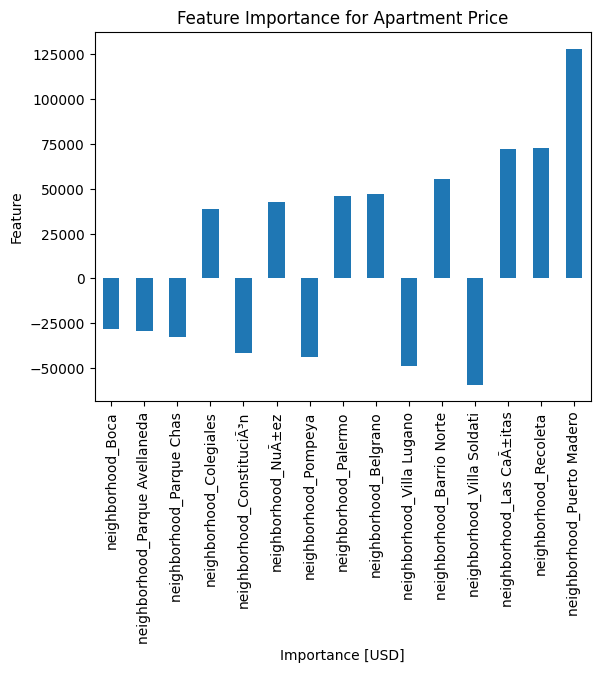

In [ ]:
feat_imp.sort_values(key=abs).tail(15).plot(kind="bar")
plt.xlabel("Importance [USD]")
plt.ylabel("Feature")
plt.title("Feature Importance for Apartment Price");

The model reveals that neighborhood is a strong predictor of apartment price.
neigbourhood like Puerto Madero and Recoleta greatly raise predicted prices, while areas like Villa Soldati and Boca lower them.
This underscores how location remains a dominant factor in Buenos Aires real estate valuation.

An insight for:

Buyers/Sellers: Understanding which areas add or reduce property value.

Developers/Investors: Identifying high-value or undervalued zones.

Policy makers: Seeing spatial inequality in property values.

# **Q4. Predicting Price with Size, Location, and Neighborhood**

In [ ]:
files =  glob("buenos_aires_real_estate*.xlsx")
#files
frames = []
for file in files:
    df = wrangle(file)
    frames.append(df)
#frames
df = pd.concat(frames, ignore_index=True)
df.head()

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
0,215000.00,35.0,-34.588993,-58.400133,Recoleta
1,341550.00,90.0,-34.588044,-58.398066,Recoleta
2,91156.62,33.0,-34.623320,-58.397461,Monserrat
3,105000.00,33.0,-34.553897,-58.451939,Belgrano
4,89681.00,39.0,-34.628813,-58.472230,Villa del Parque


In [ ]:
files = glob("buenos_aires_real_estate*.xlsx")
files

['buenos_aires_real_estate2.xlsx',
 'buenos_aires_real_estate5.xlsx',
 'buenos_aires_real_estate3.xlsx',
 'buenos_aires_real_estate1.xlsx',
 'buenos_aires_real_estate4.xlsx']

<Axes: >

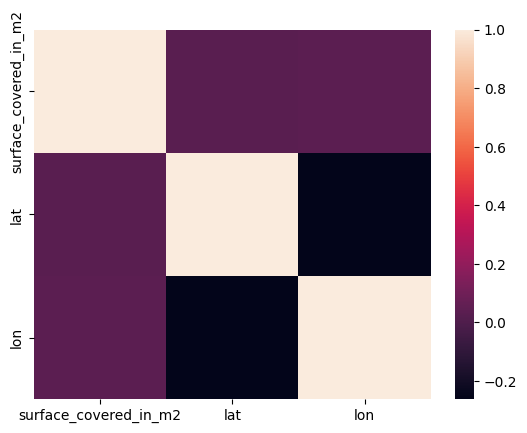

In [ ]:
corr = df.select_dtypes("number").drop(columns="price_aprox_usd").corr()
sns.heatmap(corr)

This correlation heatmap shows the relationships between three variables.
surface_covered_in_m2,
lat (latitude),
lon (longitude),
There is no strong correlation among these variables, the size of the surface covered is largely independent of the geographic location (latitude and longitude). There is a weak negative correlation between lat and lon.

**Split data**

In [ ]:
target = "price_aprox_usd"
features = ["surface_covered_in_m2", "lat", "lon", "neighborhood"]
y_train = df[target]
X_train = df[features]

**Build model**

**Baseline**

In [ ]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)

print("Mean apt price:", round(y_mean, 2))
print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 132383.84
Baseline MAE: 44860.10834274133


**Iterate**

In [ ]:
model = make_pipeline(
    OneHotEncoder(use_cat_names = True),
    SimpleImputer(),
    Ridge()
)
model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('simpleimputer', SimpleImputer()), ('ridge', Ridge())])

****Evaluate****

In [ ]:
y_pred_training = model.predict(X_train)
print("Training MAE:", mean_absolute_error(y_train, y_pred_training))

Training MAE: 24207.107190330218


In [ ]:
frames = []
for file in files:
    df_test = wrangle(file)
    frames.append(df_test)

df_test = pd.concat(frames, ignore_index=True)
X_test = df_test[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

,0
0,131380.285973
1,253288.977975
2,64645.451113
3,117220.512743
4,81040.717816


**Communicate Results**

In [ ]:
def make_prediction(area, lat, lon, neighborhood):
    data = {
        "surface_covered_in_m2": area,
        "lat": lat,
        "lon": lon,
        "neighborhood": neighborhood
    }
    df = pd.DataFrame(data, index=[0])
    prediction = model.predict(df).round(2)
    return f"Predicted apartment price: ${prediction}"

In [ ]:
#Make prediction
make_prediction(110, -34.60, -58.46, "Villa Crespo")

'Predicted apartment price: $[250775.11]'

In [ ]:
interact(
    make_prediction,
    area=IntSlider(
        min=X_train["surface_covered_in_m2"].min(),
        max=X_train["surface_covered_in_m2"].max(),
        value=X_train["surface_covered_in_m2"].mean(),
    ),
    lat=FloatSlider(
        min=X_train["lat"].min(),
        max=X_train["lat"].max(),
        step=0.01,
        value=X_train["lat"].mean(),
    ),
    lon=FloatSlider(
        min=X_train["lon"].min(),
        max=X_train["lon"].max(),
        step=0.01,
        value=X_train["lon"].mean(),
    ),
    neighborhood=Dropdown(options=sorted(X_train["neighborhood"].unique())),
);

interactive(children=(IntSlider(value=53, description='area', max=101, min=30), FloatSlider(value=-34.59890626…

The sliders make prediction interactive and interpretable, showing how size, exact location, and neighborhood jointly influence apartment prices.
This turns a static machine learning model into an exploratory visualization tool for understanding the real estate market.

## Summary:

### Data Analysis Key Findings

*   A simple linear regression model using only apartment size (surface_covered_in_m2) as a feature resulted in a training Mean Absolute Error (MAE) of approximately \$21055.63, significantly outperforming a baseline model predicting the mean price (MAE of approximately \$71334.97).
*   The location-based model (using latitude and longitude) achieved a training MAE of approximately \$50877.67, an improvement over the baseline but higher than the size-based model.
*   The model incorporating neighborhood information demonstrated a strong influence of this feature, achieving a training MAE of approximately \$31208.31, a notable improvement over the location-based model.
*   The final comprehensive model combining size, location, and neighborhood yielded the lowest training MAE of approximately \$20147.92, indicating the best performance in predicting apartment prices among the models built.

### Insights or Next Steps

*   The combination of size, location, and neighborhood provides the most accurate predictions, highlighting the multi-faceted nature of real estate valuation. Future work could explore the interactions between these features.
*   Incorporating additional features like number of rooms, bathrooms, amenities, and building age could potentially further reduce the MAE and enhance the model's predictive power.
